Aprendizado de variedades (Manifold Learning) com fluxo de clusterização distribuída por tipo de característica é mais informativo do que o UMAP para conjuntos de dados clínicos tabulares

Importando as Libraries

In [1]:
import sys
import os

# Ajusta o caminho para encontrar os módulos do FDC
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Diretório atual: {current_dir}")
print(f"Diretório pai adicionado: {parent_dir}")

Diretório atual: c:\Católica\IA\Clinical-database\FDC_Low_Dimension\Jupyter Notebooks
Diretório pai adicionado: c:\Católica\IA\Clinical-database\FDC_Low_Dimension


In [2]:
import subprocess
import sys, os
sys.path.insert(0, os.path.abspath('../../FDC_Intermediate_Dimension'))

# Instala pacotes necessários que podem estar faltando
packages_to_install = ['yellowbrick']

for package in packages_to_install:
    try:
        __import__(package)
        print(f"✓ {package} já está instalado")
    except ImportError:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} instalado com sucesso")

✓ yellowbrick já está instalado


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
import math
import umap.umap_ as umap
%config InlineBackend.figure_format = 'svg'

In [4]:
from cluster_val import *

Importando os dados

In [5]:
np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
data_with_target=pd.read_csv('../Datasets/preprocessed_migraine_data.csv')

In [6]:
np.random.seed(42)
data=data_with_target.sample(frac=1) #Shuffle the data set
np.random.seed(42)
i=[x for x in range(400)]

data.set_index(pd.Series(i), inplace=True)

In [7]:
data.drop(['Unnamed: 0','Type'],axis=1,inplace=True)

UMAP nos dados originais

In [8]:
from fdc.fdc import feature_clustering

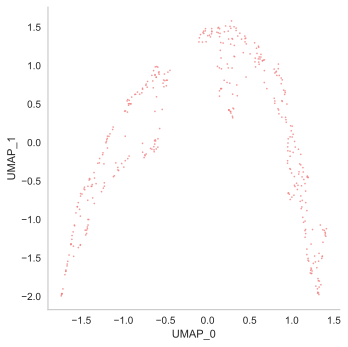

In [9]:
umap_emb=feature_clustering(15,0.1,'euclidean',data,True)

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando k-means

In [10]:
from fdc.clustering import Clustering

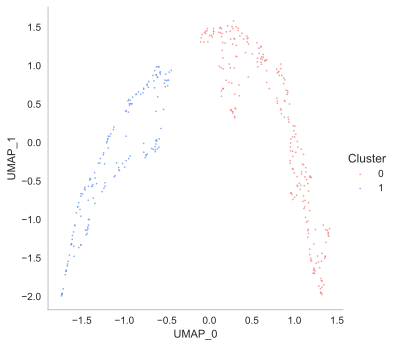

In [11]:
umap_clustering=Clustering(umap_emb,umap_emb,True)
umap_cluster_list,umap_cluster_counts=umap_clustering.K_means(2)

In [12]:
cont_list=['Age']

ord_list=['Duration','Frequency','Intensity','Visual','Nausea', 'Vomit']

nom_list=['Location','Character','Dysphasia', 'Vertigo', 'Tinnitus','Sensory','Phonophobia','Photophobia', 'Hypoacusis', 'Diplopia', 'Defect','Conscience', 'Paresthesia', 'DPF']

In [13]:


### ANOVA TEST

data['Cluster']=umap_cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  14.29 %
percentage of ordinal features having p-value less than 0.05:  16.666666666666664 %
percentage of  nominal features having p-value less than 0.05:  7.142857142857142 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [14]:
from sklearn import metrics
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score

In [15]:
silhouette_score(umap_emb, umap_cluster_list, metric='euclidean')

0.5032854083336068

Visualizing Silhouette score (Pode-se escolher o número de clusters baseado no score)

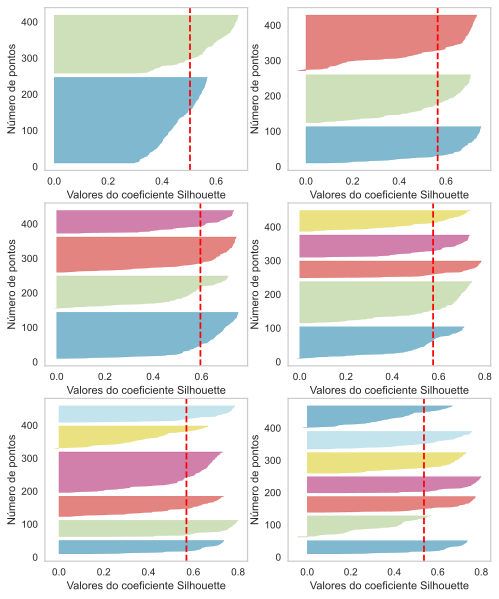

In [16]:
Silhouette_visual(umap_emb)

Elbow plot para umap_embedding

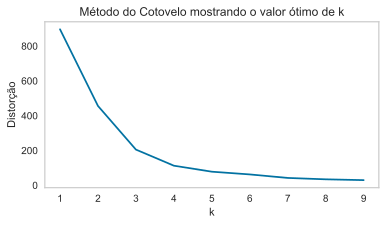

In [17]:
elbow_plot(umap_emb)

In [18]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list))

0.13629724205568197

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering Aglomerativo

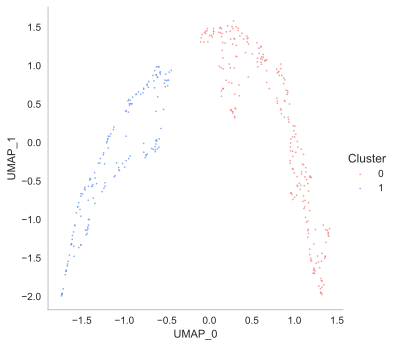

In [19]:
umap_cluster_list_agglo,umap_cluster_counts_agglo=umap_clustering.Agglomerative(2,'euclidean','ward')

In [20]:

### ANOVA TEST


data['Cluster']=umap_cluster_list_agglo
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  14.29 %
percentage of ordinal features having p-value less than 0.05:  16.666666666666664 %
percentage of  nominal features having p-value less than 0.05:  7.142857142857142 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [21]:
silhouette_score(umap_emb, umap_cluster_list_agglo, metric='euclidean')

0.5032854083336068

In [22]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_agglo))

0.13629724205568197

ANOVA test, Silhouette_score e Dunn index para clusters UMAP extraidos usando clustering do DBSCAN

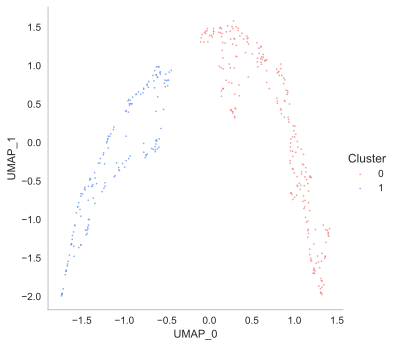

In [23]:
umap_cluster_list_dbscan,umap_cluster_counts_dbscan=umap_clustering.DBSCAN(0.5,20)

In [24]:


### ANOVA TEST

data['Cluster']=umap_cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  14.29 %
percentage of ordinal features having p-value less than 0.05:  16.666666666666664 %
percentage of  nominal features having p-value less than 0.05:  7.142857142857142 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [25]:
#removing noise indices from the embeddings
non_noise_indices= np.where(np.array(umap_cluster_list_dbscan)!=-1)
umap_emb= umap_emb.iloc[non_noise_indices]
#FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
umap_cluster_list_dbscan= np.array(umap_cluster_list_dbscan)[non_noise_indices]


In [26]:
silhouette_score(umap_emb, umap_cluster_list_dbscan, metric='euclidean')

0.5032854083336068

In [27]:
dunn_index(cluster_wise_df(umap_emb,umap_cluster_list_dbscan))

0.13629724205568197

Dividindo as variaveis
- cont_list = continuas
- ord_list = ordinais
-  nom_list  = nominais

In [28]:
cont_list=['Age']

ord_list=['Duration','Frequency','Intensity','Visual','Nausea', 'Vomit']
nom_list=['Location','Character','Dysphasia', 'Vertigo', 'Tinnitus','Sensory','Phonophobia','Photophobia', 'Hypoacusis', 'Diplopia', 'Defect','Conscience', 'Paresthesia', 'DPF']

In [29]:
len(ord_list)

6

In [30]:
len(nom_list)

14

In [31]:
len(cont_list)

1

Usando FDC nos dados originais

In [32]:
from fdc.fdc import FDC, Clustering
from fdc.fdc import canberra_modified
modified_can = canberra_modified

FDC.normalize (init): 0.00000 / 0.000s
FDC.normalize (clustering CONT): 0.98438 / 0.984s
FDC.normalize (clustering ORD): 1.10938 / 2.094s
FDC.normalize (clustering NOM): 1.29688 / 3.391s
FDC.normalize (concat): 0.00000 / 3.391s
FDC.normalize (umap 5 -> 2): 0.37500 / 3.766s
FDC.normalize (array -> DataFrame): 0.00000 / 3.766s


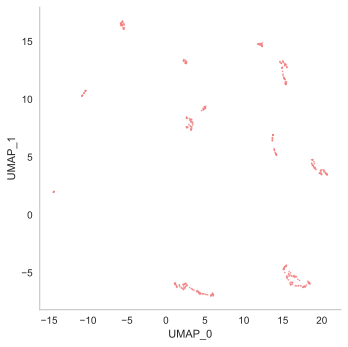

FDC.normalize (plotting): 0.37500 / 4.141s
FDC.normalize (array -> DataFrame): 0.00000 / 4.141s
FDC.normalize (total): 0.00000 / 4.141s


In [33]:

fdc = FDC(clustering_cont=Clustering('euclidean',15,0.1,max_components=1)
          , clustering_ord=Clustering(modified_can,15,0.1)
          , clustering_nom=Clustering('hamming',15,0.1)
          , visual=True
          , use_pandas_output=True
          , with_2d_embedding=True
          )

fdc.selectFeatures(continueous=cont_list, nomial=nom_list, ordinal=ord_list)

FDC_emb_high,FDC_emb_low = fdc.normalize(data,n_neighbors=15, min_dist=0.1,cont_list=cont_list, nom_list=nom_list, ord_list=ord_list,
                  with_2d_embedding=True,
                  visual=True)

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering do K-means

In [34]:
from fdc.clustering import Clustering

In [35]:
FDC_emb_low.rename(columns={"UMAP_0": "FDC_0", "UMAP_1": "FDC_1"},inplace=True)

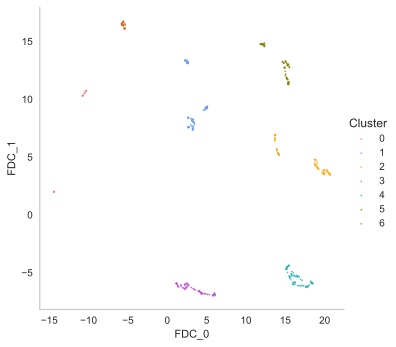

In [36]:
clustering=Clustering(FDC_emb_low,FDC_emb_low,True)
cluster_list,cluster_counts=clustering.K_means(7)

In [37]:


### ANOVA TEST

data['Cluster']=cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5,c_6)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  61.9 %
percentage of ordinal features having p-value less than 0.05:  66.66666666666666 %
percentage of  nominal features having p-value less than 0.05:  57.14285714285714 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [38]:
silhouette_score(FDC_emb_low, cluster_list, metric='euclidean')


0.7833770617415365

Visualizando Shilhouette score para fdc embedding de low_dim 

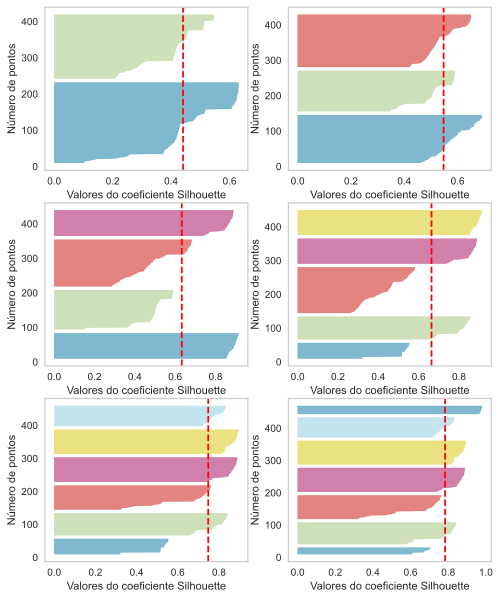

In [39]:
Silhouette_visual(FDC_emb_low)

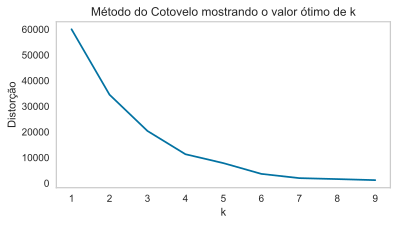

In [40]:
elbow_plot(FDC_emb_low)

In [41]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list))

0.9174169778701158

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering Aglomerativo

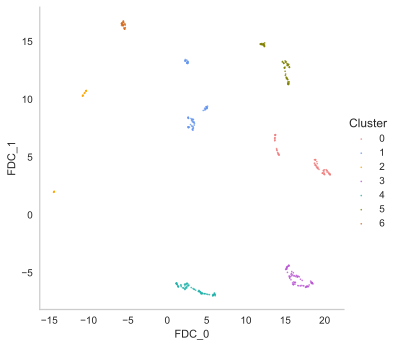

In [42]:
cluster_list_agglo,cluster_counts_agglo=clustering.Agglomerative(7,'euclidean','ward')

In [43]:

### ANOVA TEST

data['Cluster']=cluster_list
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5,c_6)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  61.9 %
percentage of ordinal features having p-value less than 0.05:  66.66666666666666 %
percentage of  nominal features having p-value less than 0.05:  57.14285714285714 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [44]:
silhouette_score(FDC_emb_low, cluster_list_agglo, metric='euclidean')

0.7891640648061586

In [45]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_agglo))

0.9174169778701158

ANOVA test, Silhouette_score e Dunn index para clusters FDC extraidos usando clustering do DBSCAN

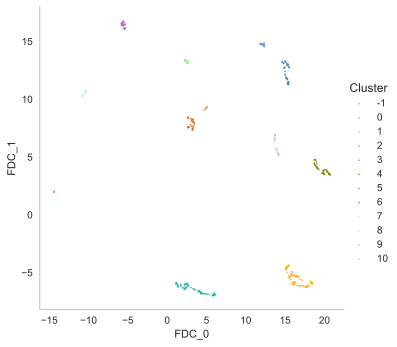

In [46]:
cluster_list_dbscan,cluster_counts_dbscan=clustering.DBSCAN(0.9,15)

In [48]:

### ANOVA TEST

data['Cluster']=cluster_list_dbscan
test_results={}
c_names=data.columns
from scipy.stats import f_oneway
for i in c_names[:-1]:
    for j in range(len(np.unique(data.Cluster))-1):#add -1 if there is noise otherwise not necessary------applicable only for DBSCAN
        var_name="c_"+str(j)
        myVars = vars()
        myVars[var_name]=list(data[i][data["Cluster"]==j])
    
    stats,p_val=f_oneway(c_0,c_1,c_2,c_3,c_4,c_5,c_7,c_8,c_9,c_10)
    test_results[i]=stats,float("{:.4f}".format(p_val))

test_results=pd.DataFrame.from_dict(test_results, orient='index', columns=["stats","p_value"])
test_column_list=test_results.index[test_results["p_value"]<0.05].to_list()
ord_count=nom_count=cont_count=0
for i in test_column_list:
    if i in ord_list:
        ord_count+=1
    elif i in nom_list:
        nom_count+=1
    elif i in cont_list:
        cont_count+=1
print('percentage of all features having p-value less than 0.05: ',float("{:.2f}".format((len(test_column_list)/(len(c_names)-1))*100)),'%')
print('percentage of ordinal features having p-value less than 0.05: ',(ord_count/len(ord_list))*100,'%')
print('percentage of  nominal features having p-value less than 0.05: ',(nom_count/len(nom_list))*100,'%')
print('percentage of continous features having p-value less than 0.05: ',(cont_count/len(cont_list))*100,'%')

percentage of all features having p-value less than 0.05:  66.67 %
percentage of ordinal features having p-value less than 0.05:  83.33333333333334 %
percentage of  nominal features having p-value less than 0.05:  57.14285714285714 %
percentage of continous features having p-value less than 0.05:  100.0 %


In [49]:
#removing noise indices from the embeddings
non_noise_indices= np.where(np.array(cluster_list)!=-1)
FDC_emb_high= FDC_emb_high.iloc[non_noise_indices]
FDC_emb_low= FDC_emb_low.iloc[non_noise_indices]
cluster_list= np.array(cluster_list)[non_noise_indices]


In [50]:
silhouette_score(FDC_emb_low, cluster_list_dbscan, metric='euclidean')

0.8899874902809838

In [51]:
dunn_index(cluster_wise_df(FDC_emb_low,cluster_list_dbscan))

0.8664892819260106